# Week 1 — Data Acquisition, Cleaning, and Preprocessing

## Virtual Data Science with Python Trainee

### Dataset: UCI Adult (Census Income) Dataset

**Objective:**  
Acquire a publicly available dataset, investigate its quality, identify missing values,
duplicates, inconsistencies, and potential outliers, and prepare the data for further
analysis using Python.

### Workflow

1. Data Acquisition
2. Initial Data Exploration
3. Missing Value Analysis
4. Data Quality Validation
5. Outlier Detection
6. Data Cleaning
7. Data Preprocessing
8. Final Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
RAW_PATH = Path("../data/raw/adult_features_raw.csv")

df = pd.read_csv(RAW_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 48,842
Columns: 14


In [3]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
dtypes: int64(6), str(8)
memory usage: 5.2 MB


In [5]:
missing_values = df.isna().sum()

missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

missing_values

occupation        966
workclass         963
native-country    274
dtype: int64

In [6]:
question_mark_counts = (df == "?").sum()

question_mark_counts = question_mark_counts[
    question_mark_counts > 0
].sort_values(ascending=False)

question_mark_counts

occupation        1843
workclass         1836
native-country     583
dtype: int64

In [9]:
missing_mask = df.isna() | df.eq("?")

combined_missing = missing_mask.sum().sort_values(
    ascending=False
)

combined_missing[combined_missing > 0]
print("Rows containing at least one missing value:",
      missing_mask.any(axis=1).sum())

print("Complete rows:",
      (~missing_mask.any(axis=1)).sum())

Rows containing at least one missing value: 3620
Complete rows: 45222


In [10]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 53


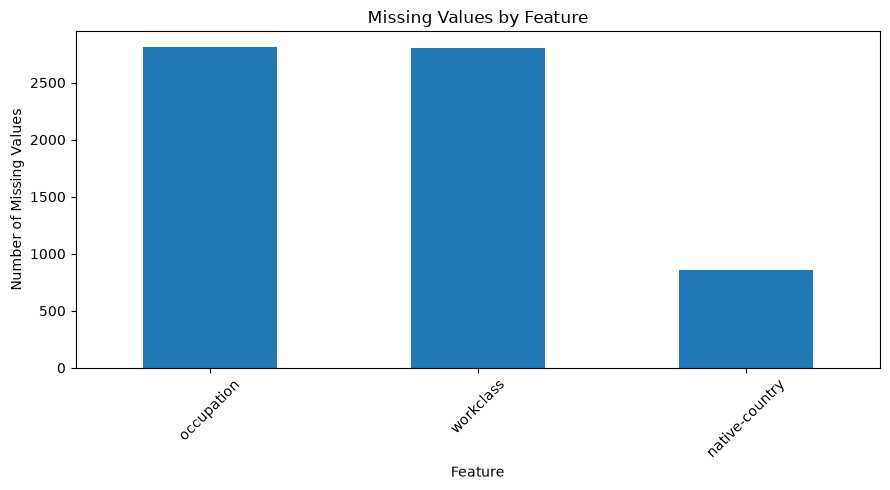

In [11]:
missing_plot = combined_missing[combined_missing > 0]

plt.figure(figsize=(9, 5))
missing_plot.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

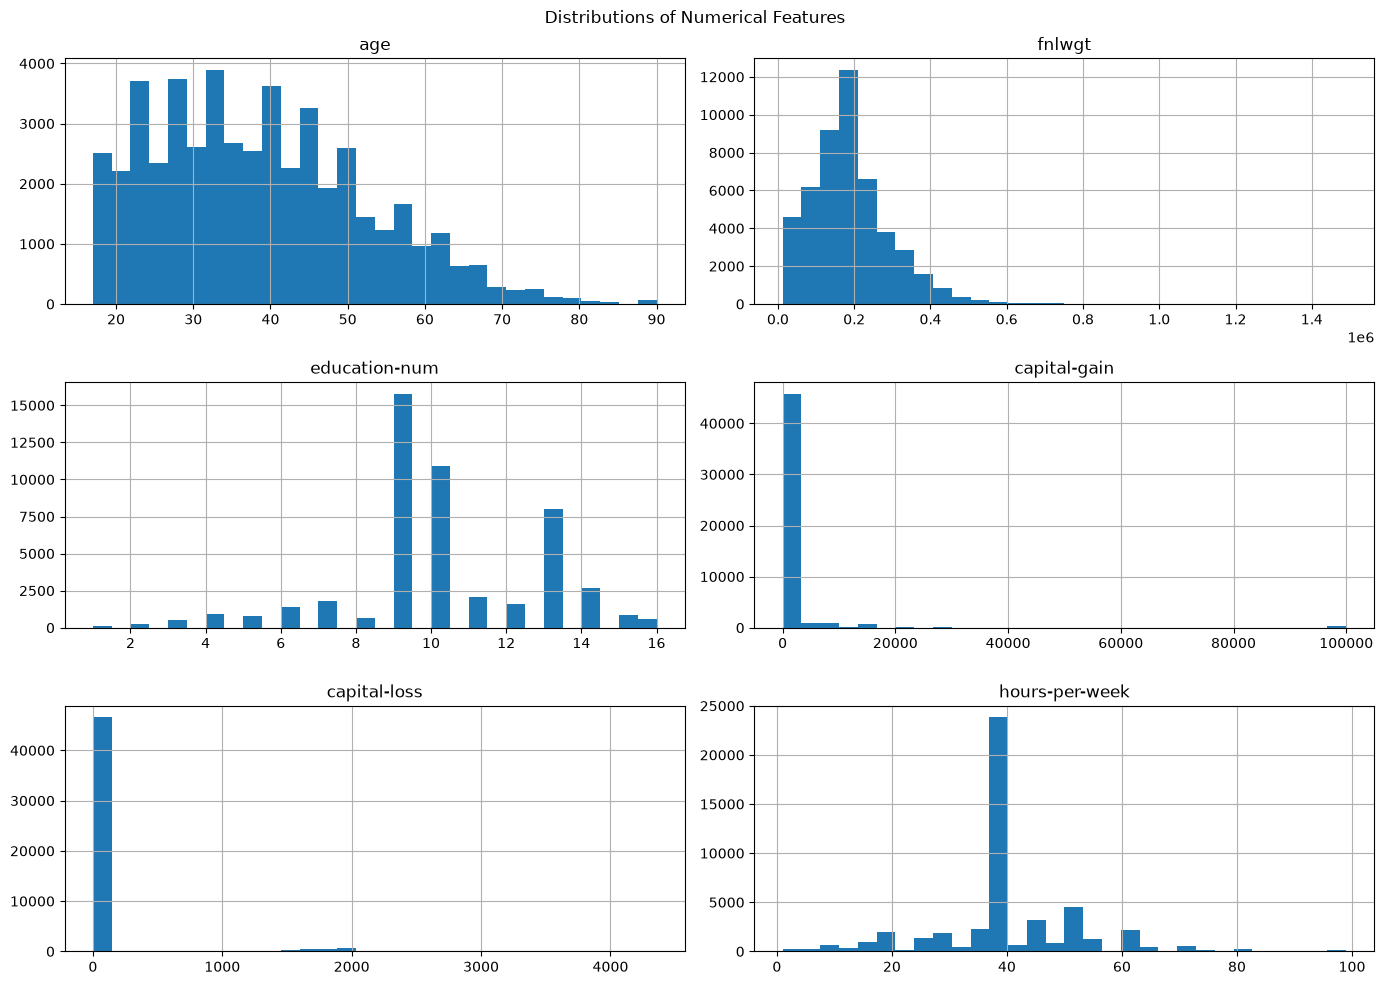

In [12]:
numeric_columns = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

df[numeric_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distributions of Numerical Features")
plt.tight_layout()
plt.show()

## 7. Logical Value Validation

Potentially invalid values were checked using reasonable domain boundaries. Values outside these boundaries would require investigation before analysis.

In [13]:
validation_results = {
    "Age below 17": (df["age"] < 17).sum(),
    "Age above 100": (df["age"] > 100).sum(),
    "Education-num below 1": (df["education-num"] < 1).sum(),
    "Education-num above 16": (df["education-num"] > 16).sum(),
    "Hours below 1": (df["hours-per-week"] < 1).sum(),
    "Hours above 168": (df["hours-per-week"] > 168).sum(),
    "Negative capital-gain": (df["capital-gain"] < 0).sum(),
    "Negative capital-loss": (df["capital-loss"] < 0).sum()
}

pd.Series(validation_results)

Age below 17              0
Age above 100             0
Education-num below 1     0
Education-num above 16    0
Hours below 1             0
Hours above 168           0
Negative capital-gain     0
Negative capital-loss     0
dtype: int64

In [14]:
cleaned_path = Path("../data/processed/adult_features_cleaned.csv")

cleaned_df = pd.read_csv(cleaned_path)

print("Cleaned dataset loaded successfully.")
print(f"Rows: {cleaned_df.shape[0]:,}")
print(f"Columns: {cleaned_df.shape[1]}")
print(f"Missing values: {cleaned_df.isna().sum().sum()}")
print(f"Duplicate rows: {cleaned_df.duplicated().sum()}")

Cleaned dataset loaded successfully.
Rows: 48,784
Columns: 14
Missing values: 0
Duplicate rows: 0


In [15]:
comparison = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Rows"
    ],
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        (df.isna() | df.eq("?")).sum().sum(),
        df.duplicated().sum()
    ],
    "After Cleaning": [
        cleaned_df.shape[0],
        cleaned_df.shape[1],
        cleaned_df.isna().sum().sum(),
        cleaned_df.duplicated().sum()
    ]
})

comparison

,Metric,Before Cleaning,After Cleaning
0,Rows,48842,48784
1,Columns,14,14
2,Missing Values,6465,0
3,Duplicate Rows,53,0


In [16]:
preprocessed_path = Path(
    "../data/processed/adult_features_preprocessed.csv"
)

preprocessed_df = pd.read_csv(preprocessed_path)

print("Preprocessed dataset loaded successfully.")
print(f"Rows: {preprocessed_df.shape[0]:,}")
print(f"Features: {preprocessed_df.shape[1]}")
print(f"Missing values: {preprocessed_df.isna().sum().sum()}")

Preprocessed dataset loaded successfully.
Rows: 48,784
Features: 105
Missing values: 0


In [17]:
preprocessing_summary = pd.DataFrame({
    "Stage": [
        "Raw dataset",
        "Cleaned dataset",
        "Preprocessed dataset"
    ],
    "Rows": [
        df.shape[0],
        cleaned_df.shape[0],
        preprocessed_df.shape[0]
    ],
    "Columns / Features": [
        df.shape[1],
        cleaned_df.shape[1],
        preprocessed_df.shape[1]
    ]
})

preprocessing_summary

,Stage,Rows,Columns / Features
0,Raw dataset,48842,14
1,Cleaned dataset,48784,14
2,Preprocessed dataset,48784,105


In [18]:
print("=" * 70)
print("FINAL DATA QUALITY VALIDATION")
print("=" * 70)

print("\nCleaned dataset:")
print("Shape:", cleaned_df.shape)
print("Missing values:", cleaned_df.isna().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

print("\nPreprocessed dataset:")
print("Shape:", preprocessed_df.shape)
print("Missing values:", preprocessed_df.isna().sum().sum())
print("Duplicate rows:", preprocessed_df.duplicated().sum())

print("\nWeek 1 data preparation completed successfully.")

FINAL DATA QUALITY VALIDATION

Cleaned dataset:
Shape: (48784, 14)
Missing values: 0
Duplicate rows: 0

Preprocessed dataset:
Shape: (48784, 105)
Missing values: 0
Duplicate rows: 0

Week 1 data preparation completed successfully.
